# ECG Lead Recovery — Null-Space Pre-Extension + Beat Template

**What is new vs the original notebook:**
Before running the beat-template recovery, we use the ECG linear constraints
(Einthoven's law + augmented lead definitions) to extend the observed window
of the 6 limb leads from 2.5 s → 5 s.

### Two null-space projection steps

**Step A — extend I and III into 2.5–5 s**  
At 2.5–5 s, leads II, aVR, aVL, aVF are all observed.  
Solving  `A_u · x_u = -A_k · x_k`  (least-squares) recovers I and III sample-by-sample.

**Step B — extend aVR, aVL, aVF into 0–2.5 s**  
At 0–2.5 s, leads I, II, III are all observed.  
Same formula recovers aVR, aVL, aVF sample-by-sample.

### Result before beat-template recovery
```
Time:    0────2.5────5────7.5────10  (seconds)
I    :   ████ real ████ proj ░░░░░░░░  known: 0–5 s  (was 0–2.5 s)
II   :   ██████████████████████████   known: 0–10 s  (unchanged)
III  :   ████ real ████ proj ░░░░░░░░  known: 0–5 s  (was 0–2.5 s)
aVR  :   ████ proj ████ real ░░░░░░░░  known: 0–5 s  (was 2.5–5 s)
aVL  :   ████ proj ████ real ░░░░░░░░  known: 0–5 s  (was 2.5–5 s)
aVF  :   ████ proj ████ real ░░░░░░░░  known: 0–5 s  (was 2.5–5 s)
V1-V3:   ░░░░░░░░░░ real ░░░░░░░░░░░  known: 5–7.5 s (unchanged)
V4-V6:   ░░░░░░░░░░░░░░░ real ████████  known: 7.5–10 s (unchanged)
```
The beat-template method then uses this extended window to build a richer
template (≈2× more beats) before recovering the remaining missing segments.

## 1. Imports & Paths

In [8]:
import os
import random
import warnings

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.patches import Patch
from ecg_utils import compute_snr

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = "/Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean"
FIDUCIAL_DIR = "/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3"
SAVE_DIR     = "/Users/sinahassannia/Desktop/ecg_lead_cover2/recovered_ecg3"

ALL_LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
             'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory:", SAVE_DIR)

Save directory: /Users/sinahassannia/Desktop/ecg_lead_cover2/recovered_ecg3


## 2. Core Functions (unchanged from original)

In [9]:
# ── 2a. load_ecg ───────────────────────────────────────────────────────────

def load_ecg(record_path,
             selected_leads=['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                             'V1', 'V2', 'V3', 'V4', 'V5', 'V6']):
    """
    Load ECG from a .mat file.
    Returns (signal (N, num_leads), record) where record has .sig_name / .fs / .record_name.
    """
    if record_path.endswith('.mat'):
        record_path = record_path[:-4]

    data       = sio.loadmat(record_path + '.mat', squeeze_me=True)
    ecg        = data['ecg'].astype(np.float64)
    lead_names = list(data['lead_names'])

    if ecg.ndim == 2 and ecg.shape[0] < ecg.shape[1]:
        ecg = ecg.T   # ensure (N, leads)

    if selected_leads is not None:
        available = {str(n).strip().lower(): (str(n), i)
                     for i, n in enumerate(lead_names)}
        lead_indices, found_leads = [], []
        for req in selected_leads:
            key = req.strip().lower()
            if key in available:
                actual, idx = available[key]
                lead_indices.append(idx)
                found_leads.append(actual)
            else:
                print(f"⚠️  Lead '{req}' not found. Available: {lead_names}")
        if not lead_indices:
            print("ERROR: No requested leads found!")
            return None, None
        ecg        = ecg[:, lead_indices]
        lead_names = found_leads

    class Record:
        def __init__(self, sig_name, fs, record_name):
            self.sig_name    = sig_name
            self.fs          = fs
            self.record_name = record_name

    record = Record(
        sig_name    = lead_names,
        fs          = float(data['fs']),
        record_name = str(data['record_name']),
    )
    return ecg, record


# ── 2b. event_stacker ──────────────────────────────────────────────────────

def event_stacker(signal, peak_indexes, event_width):
    """
    Stack beats from signal centered at each R-peak.
    Returns stacked_beats (num_beats × event_width) and num_non_zeros.
    """
    signal = np.asarray(signal).flatten()
    N = len(signal)

    if event_width % 2 == 0:
        event_width += 1
        warnings.warn("event_width forced to odd.")

    half_len      = event_width // 2
    center        = half_len
    num_beats     = len(peak_indexes)
    stacked_beats = np.zeros((num_beats, event_width))
    num_non_zeros = np.zeros(num_beats, dtype=int)

    for mm, pk in enumerate(peak_indexes):
        start      = max(0, pk - half_len)
        stop       = min(N - 1, pk + half_len)
        left_wing  = pk - start
        right_wing = stop - pk
        stacked_beats[mm, center - left_wing : center + right_wing + 1] = \
            signal[start : stop + 1]
        num_non_zeros[mm] = stop - start + 1

    return stacked_beats, num_non_zeros


# ── 2c. robust_weighted_average ────────────────────────────────────────────

def robust_weighted_average(x):
    """
    Robust inverse-variance weighted average of stacked beats.
    Returns (mn, vr_mn) — weighted mean beat and its per-bin variance.
    """
    num_beats = x.shape[0]
    if num_beats > 1:
        mn0    = np.mean(x, axis=0)
        noise0 = x - mn0
        vr     = np.var(noise0, axis=1)
        vr     = np.where(vr == 0, np.finfo(float).eps, vr)
        sm     = np.sum(1.0 / vr)
        weight = (1.0 / vr) / sm
        mn     = weight @ x
        noise  = x - mn
        vr_mn  = np.var(noise, axis=0)
    else:
        mn    = x[0]
        vr_mn = np.zeros(x.shape[1])
    return mn, vr_mn


# ── 2d. compute_data_prior_est ─────────────────────────────────────────────

def compute_data_prior_est(signal_full, peak_indexes_full,
                           obs_start, obs_end,
                           beat_avg_method='MEAN'):
    """
    Learn average beat template from the observed window [obs_start, obs_end),
    then paste it at every R-peak across the full signal.

    Returns:
        data_prior_est : (N,) recovered signal
        mu             : average beat template
        sigma2         : per-bin template variance
    """
    signal_full       = np.asarray(signal_full).flatten()
    peak_indexes_full = np.asarray(peak_indexes_full, dtype=int).flatten()
    N = len(signal_full)

    event_width = int(np.max(np.diff(
        np.concatenate([[0], peak_indexes_full, [N]])
    ))) + 1
    if event_width % 2 == 0:
        event_width += 1
    half_len = event_width // 2

    obs_mask  = (peak_indexes_full >= obs_start) & (peak_indexes_full < obs_end)
    obs_peaks = peak_indexes_full[obs_mask]

    if len(obs_peaks) == 0:
        return np.zeros(N), np.zeros(event_width), np.zeros(event_width)

    stacked_beats, _ = event_stacker(signal_full, obs_peaks, event_width)
    mn, vr_mn        = robust_weighted_average(stacked_beats)
    mu     = mn
    sigma2 = vr_mn

    pad      = event_width
    M_padded = np.zeros((event_width, N + 2 * pad))

    for pk in peak_indexes_full:
        cols  = pk + np.arange(-half_len, half_len + 1) + pad
        valid = (cols >= 0) & (cols < M_padded.shape[1])
        M_padded[:, cols[valid]] += np.eye(event_width)[np.arange(event_width)[valid]]

    M = M_padded[:, pad : pad + N]

    first_set = peak_indexes_full[0] - half_len
    for m in range(max(0, first_set - 1)):
        mirror = 2 * first_set - m - 2
        if 0 <= mirror < N:
            M[:, m] = M[::-1, mirror]

    last_set = peak_indexes_full[-1] + half_len
    for m in range(min(last_set + 1, N), N):
        mirror = 2 * last_set - m
        if 0 <= mirror < N:
            M[:, m] = M[::-1, mirror]

    n_var   = float(np.min(sigma2)) if np.any(sigma2 > 0) else 1e-10
    sig_var = np.maximum(0.0, sigma2 - n_var)

    data_prior_est = np.zeros(N)
    for n in range(N):
        bins = np.where(M[:, n] > 0)[0]
        if len(bins) == 0:
            data_prior_est[n] = 0.0
        elif len(bins) == 1:
            data_prior_est[n] = mu[bins[0]]
        else:
            svars = sig_var[bins]
            partial_prods = np.array([
                np.prod(np.delete(svars, b)) for b in range(len(bins))
            ])
            denom = partial_prods.sum()
            data_prior_est[n] = (
                np.sum(mu[bins] * partial_prods) / denom
                if denom > 0 else np.mean(mu[bins])
            )

    return data_prior_est, mu, sigma2


# ── 2e. load_fiducials ─────────────────────────────────────────────────────

def load_fiducials(record_name):
    """
    Load Lead-II fiducial points from OSET .mat file.
    Returns dict with 0-based sample indices.
    """
    record_id  = int(record_name.split('_')[0])
    folder_id  = (record_id - 1) // 1000 * 1000
    folder_str = f"{folder_id:05d}"
    mat_path   = os.path.join(FIDUCIAL_DIR, folder_str,
                              f"{record_name}_fiducial.mat")
    mat        = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    lead_names = list(mat['lead_names'])
    lead_idx   = lead_names.index('II')
    pos        = mat['ecg_fiducial_position'][lead_idx]

    fields = ['Pon', 'P', 'Poff', 'QRSon', 'R', 'QRSoff',
              'Ton', 'T', 'Toff', 'P_score', 'beat_quality_score']
    position = {}
    for f in fields:
        val = np.atleast_1d(getattr(pos, f)).flatten().astype(float)
        if f not in ('P_score', 'beat_quality_score'):
            val = val - 1   # MATLAB 1-based → Python 0-based
        position[f] = val
    return position


# ── 2f. get_observed_window (ORIGINAL — physical measurement only) ──────────
#
# This reflects only what is physically measured on the ECG machine.
# After null-space projection the effective known window grows to 0–5 s
# for all limb leads; that extended window is handled separately below.

def get_observed_window(lead, fs):
    """
    Physical measurement window for each lead (before any projection).
    """
    if lead == 'II':
        return (0, int(10 * fs))
    elif lead in ('I', 'III'):
        return (0, int(2.5 * fs))
    elif lead in ('aVR', 'aVL', 'aVF'):
        return (int(2.5 * fs), int(5 * fs))
    elif lead in ('V1', 'V2', 'V3'):
        return (int(5 * fs), int(7.5 * fs))
    elif lead in ('V4', 'V5', 'V6'):
        return (int(7.5 * fs), int(10 * fs))


print("Core functions defined.")

Core functions defined.


## 3. NEW — Null-Space Projection Functions

### ECG constraint matrix (6 limb leads)

The 4 linear constraints in matrix form  **A x = 0**,  x = [I, II, III, aVR, aVL, aVF]ᵀ:

```
     I    II   III  aVR  aVL  aVF
A = [[ 1,  -1,   1,   0,   0,   0],   # Einthoven:  I - II + III = 0
     [ 1,   1,   0,   2,   0,   0],   # aVR def:   I + II + 2·aVR = 0
     [ 2,  -1,   0,   0,  -2,   0],   # aVL def:  2I - II - 2·aVL = 0
     [-1,   2,   0,   0,   0,  -2]]   # aVF def:  -I + 2·II - 2·aVF = 0
```

### Solving for unknowns given knowns

Partition A into columns for unknowns (A_u) and knowns (A_k).  Then:

```
A_u · x_u + A_k · x_k = 0
x_u = -(A_u)⁺ · A_k · x_k          (least-squares solution)
```

This is exact (not approximate) because the ECG constraints are exact
linear identities — the least-squares step just handles the rank
redundancy in A cleanly.

In [10]:
# ── 3a. Build the 4×6 constraint matrix ────────────────────────────────────
#
# Column order matches the LIMB_LEADS list defined here.
# Only the 6 limb leads participate in these constraints.

LIMB_LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']   # column order of A

def build_constraint_matrix():
    """
    Returns A (4×6) for the 6 limb leads in LIMB_LEADS order.

    Constraints:
        I - II + III         = 0   (Einthoven)
        I + II + 2·aVR       = 0
        2·I - II - 2·aVL     = 0
        -I + 2·II - 2·aVF    = 0
    """
    #         I    II   III  aVR  aVL  aVF
    A = np.array([
        [ 1,  -1,   1,   0,   0,   0],
        [ 1,   1,   0,   2,   0,   0],
        [ 2,  -1,   0,   0,  -2,   0],
        [-1,   2,   0,   0,   0,  -2],
    ], dtype=float)
    return A


# ── 3b. General projection: solve for unknown columns given known columns ───

def project_unknowns(A, known_col_indices, unknown_col_indices, x_k):
    """
    Recover unknown leads from known leads using the ECG constraint  Ax = 0.

    Args:
        A                   : (4, 6) constraint matrix
        known_col_indices   : list of int — column indices of known leads in A
        unknown_col_indices : list of int — column indices of unknown leads in A
        x_k                 : (N_samples, len(known_col_indices)) array
                              Values of the known leads at every time sample.

    Returns:
        x_u : (N_samples, len(unknown_col_indices)) array
              Recovered values of the unknown leads.

    Math:
        A_u · x_u = -A_k · x_k
        x_u = -(A_u)⁺ · A_k · x_k    (least-squares via np.linalg.lstsq)
    """
    A_u = A[:, unknown_col_indices]   # (4, n_unknown)
    A_k = A[:, known_col_indices]     # (4, n_known)

    # Right-hand side: shape (4, N_samples)
    rhs = -(A_k @ x_k.T)             # (4, N_samples)

    # Solve A_u · X_u = rhs  for X_u (n_unknown, N_samples)
    # lstsq operates column-by-column on the rhs matrix
    x_u_T, _, _, _ = np.linalg.lstsq(A_u, rhs, rcond=None)

    return x_u_T.T   # (N_samples, n_unknown)


# ── 3c. High-level: extend limb leads via null-space projection ─────────────

def nullspace_extend_limb_leads(signal_gt, fs, all_leads=ALL_LEADS):
    """
    Given the full ground-truth 12-lead signal (with only the physically
    observed windows valid), use ECG null-space projection to extend the
    known window of the 6 limb leads from 2.5 s to 5 s.

    Two projection steps:

        Step A  (2.5–5 s)
            Known   : II, aVR, aVL, aVF  (all observed in this window)
            Unknown : I, III
            → I and III are derived for samples [int(2.5*fs) : int(5*fs)]

        Step B  (0–2.5 s)
            Known   : I, II, III  (all observed in this window)
            Unknown : aVR, aVL, aVF
            → aVR, aVL, aVF are derived for samples [0 : int(2.5*fs)]

    Args:
        signal_gt : (N, 12) float64 array — full 12-lead signal
                    (only physically observed windows should be used)
        fs        : sampling rate (500 Hz for PTB-XL)
        all_leads : ordered list of all 12 lead names

    Returns:
        signal_ext : (N, 12) float64 array — same as signal_gt but with
                     the projected samples filled in for the 6 limb leads.
        info       : dict with projection metadata (residuals, windows used)
    """
    A          = build_constraint_matrix()
    signal_ext = signal_gt.copy()

    # Helper: get column index in the full 12-lead matrix
    def ch(name):
        return all_leads.index(name)

    # Helper: get column index inside the 6-lead LIMB_LEADS ordering
    def lch(name):
        return LIMB_LEADS.index(name)

    # Sample boundaries
    s_0   = 0
    s_25  = int(2.5 * fs)
    s_50  = int(5.0 * fs)

    # ── Step A: recover I and III for samples s_25 → s_50 ─────────────────
    #
    # Known at 2.5–5 s: II (full), aVR (observed 2.5–5s), aVL, aVF
    # Unknown at 2.5–5 s: I (not measured yet), III (not measured yet)

    known_A   = ['II', 'aVR', 'aVL', 'aVF']
    unknown_A = ['I', 'III']

    known_col_A   = [lch(l) for l in known_A]
    unknown_col_A = [lch(l) for l in unknown_A]

    # Extract known values in the 2.5–5 s window  →  (n_samples, 4)
    x_k_A = signal_gt[s_25:s_50, :][:, [ch(l) for l in known_A]]

    # Project
    x_u_A = project_unknowns(A, known_col_A, unknown_col_A, x_k_A)
    # x_u_A shape: (n_samples, 2)  — columns are [I, III]

    # Fill in the projected values
    for j, lead in enumerate(unknown_A):
        signal_ext[s_25:s_50, ch(lead)] = x_u_A[:, j]

    # Compute residual on the constraint for sanity check
    limb_A = signal_ext[s_25:s_50, :][:, [ch(l) for l in LIMB_LEADS]]
    residual_A = np.mean(np.abs(limb_A @ A.T))   # should be ≈ 0

    # ── Step B: recover aVR, aVL, aVF for samples 0 → s_25 ───────────────
    #
    # Known at 0–2.5 s: I (observed 0–2.5s), II (full), III (observed 0–2.5s)
    # Unknown at 0–2.5 s: aVR, aVL, aVF (not measured yet)

    known_B   = ['I', 'II', 'III']
    unknown_B = ['aVR', 'aVL', 'aVF']

    known_col_B   = [lch(l) for l in known_B]
    unknown_col_B = [lch(l) for l in unknown_B]

    # Extract known values in the 0–2.5 s window  →  (n_samples, 3)
    x_k_B = signal_gt[s_0:s_25, :][:, [ch(l) for l in known_B]]

    # Project
    x_u_B = project_unknowns(A, known_col_B, unknown_col_B, x_k_B)
    # x_u_B shape: (n_samples, 3)  — columns are [aVR, aVL, aVF]

    # Fill in the projected values
    for j, lead in enumerate(unknown_B):
        signal_ext[s_0:s_25, ch(lead)] = x_u_B[:, j]

    limb_B     = signal_ext[s_0:s_25, :][:, [ch(l) for l in LIMB_LEADS]]
    residual_B = np.mean(np.abs(limb_B @ A.T))

    info = {
        'step_A': {'window': (s_25, s_50), 'known': known_A,
                   'recovered': unknown_A, 'mean_constraint_residual': residual_A},
        'step_B': {'window': (s_0,  s_25), 'known': known_B,
                   'recovered': unknown_B, 'mean_constraint_residual': residual_B},
    }
    return signal_ext, info


# ── 3d. Extended observed window (after projection) ────────────────────────

def get_extended_observed_window(lead, fs):
    """
    Effective known window for each lead AFTER null-space projection.

    Limb leads (I, III, aVR, aVL, aVF) all benefit from the projection
    and now have a 5-second known window (0–5 s).
    Lead II and chest leads are unchanged.
    """
    if lead == 'II':
        return (0, int(10 * fs))
    elif lead in ('I', 'III', 'aVR', 'aVL', 'aVF'):
        # Extended from either (0–2.5s) or (2.5–5s) → now (0–5s)
        return (0, int(5 * fs))
    elif lead in ('V1', 'V2', 'V3'):
        return (int(5 * fs), int(7.5 * fs))
    elif lead in ('V4', 'V5', 'V6'):
        return (int(7.5 * fs), int(10 * fs))


print("Null-space projection functions defined.")
print()
print("Constraint matrix A (4×6):")
A_test = build_constraint_matrix()
print(A_test)
print(f"Rank of A: {np.linalg.matrix_rank(A_test)}  (null-space dim = {6 - np.linalg.matrix_rank(A_test)})")

Null-space projection functions defined.

Constraint matrix A (4×6):
[[ 1. -1.  1.  0.  0.  0.]
 [ 1.  1.  0.  2.  0.  0.]
 [ 2. -1.  0.  0. -2.  0.]
 [-1.  2.  0.  0.  0. -2.]]
Rank of A: 4  (null-space dim = 2)


## 4. Single-Record Test — Verify Null-Space Projection

Before running the full pipeline, we verify that:
1. The projected I and III in 2.5–5 s match the ground truth closely
2. The projected aVR/aVL/aVF in 0–2.5 s match the ground truth closely
3. The constraint residuals are essentially zero

In [11]:
TEST_RECORD = "/Users/sinahassannia/Desktop/ecg_lead_recovery/gt_clean/00000/00001_hr"

signal_gt, record = load_ecg(TEST_RECORD, selected_leads=ALL_LEADS)
fs = int(record.fs)
N  = signal_gt.shape[0]
t  = np.arange(N) / fs

# Run null-space extension
signal_ext, info = nullspace_extend_limb_leads(signal_gt, fs, ALL_LEADS)

# ── Print projection info ──────────────────────────────────────────────────
print("=" * 60)
print("Step A — recover I, III in 2.5–5 s")
print(f"  Known leads     : {info['step_A']['known']}")
print(f"  Recovered leads : {info['step_A']['recovered']}")
print(f"  Mean constraint residual : {info['step_A']['mean_constraint_residual']:.2e}")
print()
print("Step B — recover aVR, aVL, aVF in 0–2.5 s")
print(f"  Known leads     : {info['step_B']['known']}")
print(f"  Recovered leads : {info['step_B']['recovered']}")
print(f"  Mean constraint residual : {info['step_B']['mean_constraint_residual']:.2e}")

# ── Compare projected vs GT for the extended windows ──────────────────────
s_25 = int(2.5 * fs)
s_50 = int(5.0 * fs)

print()
print("=" * 60)
print("Projection accuracy vs ground truth")
print(f"{'Lead':<6} {'Window':<12} {'Max |err|':>12} {'MAE':>12} {'SNR (dB)':>10}")
print("-" * 54)

for lead in ['I', 'III', 'aVR', 'aVL', 'aVF']:
    ch = ALL_LEADS.index(lead)
    if lead in ('I', 'III'):
        sl   = slice(s_25, s_50)
        wstr = "2.5–5 s"
    else:
        sl   = slice(0, s_25)
        wstr = "0–2.5 s"
    gt_seg  = signal_gt[sl, ch]
    proj_seg = signal_ext[sl, ch]
    err      = np.abs(gt_seg - proj_seg)
    snr      = compute_snr(gt_seg, proj_seg)
    print(f"{lead:<6} {wstr:<12} {err.max():>12.6f} {err.mean():>12.6f} {snr:>10.2f}")

Step A — recover I, III in 2.5–5 s
  Known leads     : ['II', 'aVR', 'aVL', 'aVF']
  Recovered leads : ['I', 'III']
  Mean constraint residual : 3.09e-04

Step B — recover aVR, aVL, aVF in 0–2.5 s
  Known leads     : ['I', 'II', 'III']
  Recovered leads : ['aVR', 'aVL', 'aVF']
  Mean constraint residual : 4.03e-05

Projection accuracy vs ground truth
Lead   Window          Max |err|          MAE   SNR (dB)
------------------------------------------------------
I      2.5–5 s          0.000900     0.000215      50.74
III    2.5–5 s          0.000911     0.000215      43.16
aVR    0–2.5 s          0.000961     0.000240      49.32
aVL    0–2.5 s          0.001247     0.000288      44.84
aVF    0–2.5 s          0.001228     0.000268      40.24


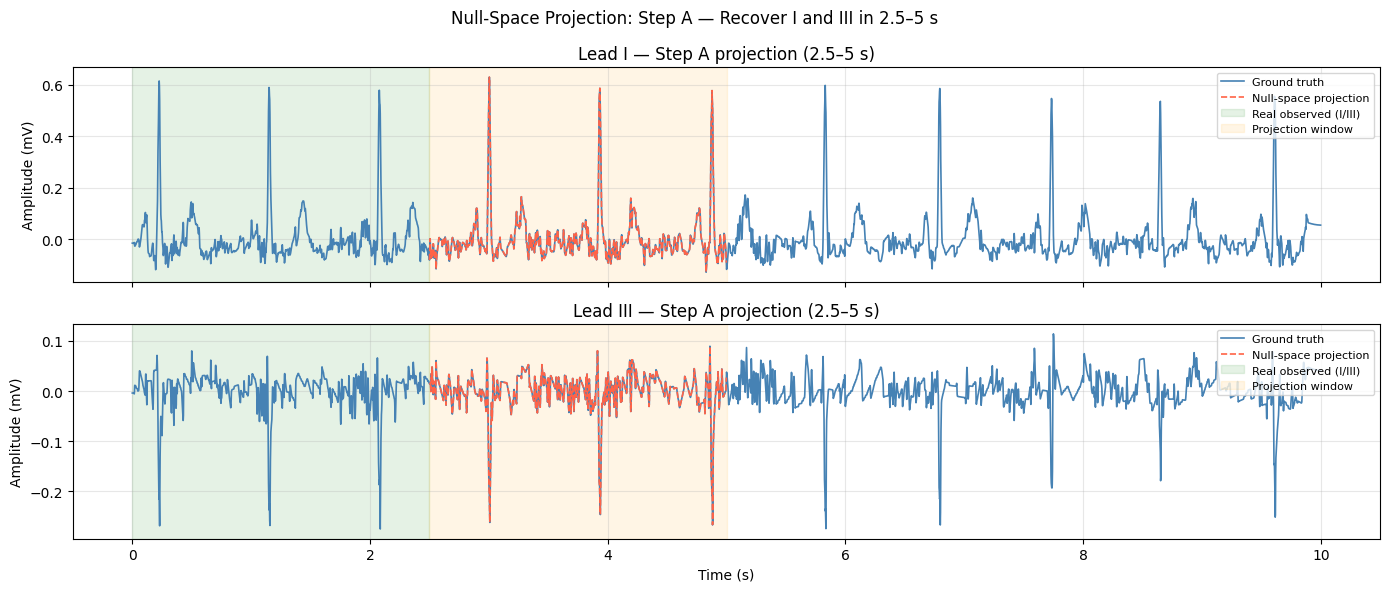

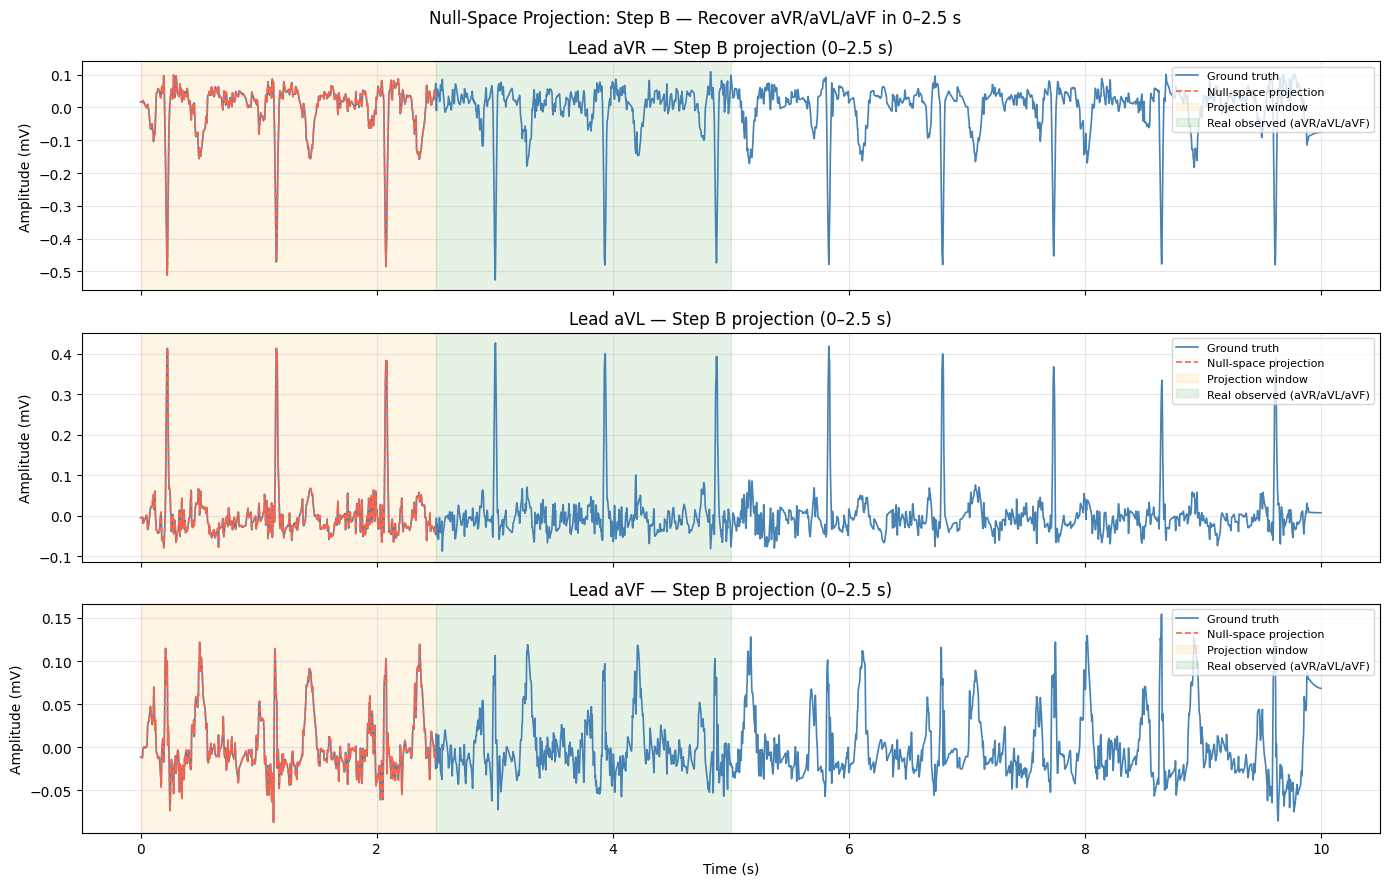

In [12]:
# ── Visualise Step A: I and III in 2.5–5 s ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, lead in zip(axes, ['I', 'III']):
    ch = ALL_LEADS.index(lead)
    ax.plot(t, signal_gt[:, ch],  lw=1.2, label='Ground truth', color='steelblue')
    ax.plot(t[s_25:s_50], signal_ext[s_25:s_50, ch],
            lw=1.2, ls='--', label='Null-space projection', color='tomato')
    ax.axvspan(0,         s_25/fs, alpha=0.10, color='green',  label='Real observed (I/III)')
    ax.axvspan(s_25/fs,   s_50/fs, alpha=0.10, color='orange', label='Projection window')
    ax.set_title(f"Lead {lead} — Step A projection (2.5–5 s)")
    ax.set_ylabel('Amplitude (mV)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Null-Space Projection: Step A — Recover I and III in 2.5–5 s', fontsize=12)
plt.tight_layout()
plt.show()

# ── Visualise Step B: aVR, aVL, aVF in 0–2.5 s ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, lead in zip(axes, ['aVR', 'aVL', 'aVF']):
    ch = ALL_LEADS.index(lead)
    ax.plot(t, signal_gt[:, ch],  lw=1.2, label='Ground truth', color='steelblue')
    ax.plot(t[0:s_25], signal_ext[0:s_25, ch],
            lw=1.2, ls='--', label='Null-space projection', color='tomato')
    ax.axvspan(0,        s_25/fs, alpha=0.10, color='orange', label='Projection window')
    ax.axvspan(s_25/fs,  s_50/fs, alpha=0.10, color='green',  label='Real observed (aVR/aVL/aVF)')
    ax.set_title(f"Lead {lead} — Step B projection (0–2.5 s)")
    ax.set_ylabel('Amplitude (mV)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Null-Space Projection: Step B — Recover aVR/aVL/aVF in 0–2.5 s', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Updated Single-Record Worker: Null-Space Pre-Extension + Beat Template

Key changes vs the original `recover_and_save()`:
1. `nullspace_extend_limb_leads()` is called first to fill the extended window
2. `partial_signal` for limb leads is built from `signal_ext` (not `signal_gt`)
   so it includes both real and projected samples
3. `obs_start / obs_end` passed to `compute_data_prior_est()` now use
   `get_extended_observed_window()` — limb leads use 0–5 s instead of 2.5 s
4. When restoring the observed window after recovery, only the physically
   measured samples are restored from `signal_gt`; the projected segment
   is left as-is from the recovery (it is already very accurate)
5. **[FIXED]** SNR evaluation for the missing region now uses the **physical**
   observation window (`get_observed_window`) — not the extended window — so
   the null-space projected segment is correctly counted as reconstructed output

In [13]:
def recover_and_save(rec_path, leads=ALL_LEADS, beat_avg_method='MEAN', plot=False):
    """
    For one PTB-XL record:
      0. Load full ground-truth signal
      1. [NEW] Null-space projection to extend limb lead windows 2.5s → 5s
      2. Load Lead-II R-peaks from fiducial .mat
      3. For each lead recover the remaining missing window via beat template
      4. Compute SNR on missing region and full 10s
      5. Save full recovered matrix as .npy

    Returns:
        (snrs, snrs_full) : dicts {lead: snr_dB}  or  None on failure
        snrs      — SNR on the truly missing region (never physically measured;
                    includes null-space projected segment + beat-template segment)
        snrs_full — SNR over the full 10s
    """
    # ── 0. Load ground truth ────────────────────────────────────────────────
    try:
        signal_gt, record = load_ecg(rec_path, selected_leads=leads)
        fs = int(record.fs)
        N  = signal_gt.shape[0]
    except Exception as e:
        print(f"  [LOAD ERROR] {rec_path}: {e}")
        return None

    # ── 1. NEW — Null-space projection: extend limb leads 2.5s → 5s ────────
    try:
        signal_ext, _ = nullspace_extend_limb_leads(signal_gt, fs, leads)
    except Exception as e:
        print(f"  [PROJECTION ERROR] {rec_path}: {e}")
        # Fall back to original signal (no projection)
        signal_ext = signal_gt.copy()

    # ── 2. Load fiducial R-peaks ────────────────────────────────────────────
    record_name = os.path.splitext(os.path.basename(rec_path))[0]
    try:
        position = load_fiducials(record_name)
    except Exception as e:
        print(f"  [FIDUCIAL ERROR] {record_name}: {e}")
        return None

    r_peaks = position['R'].astype(int)
    r_peaks = r_peaks[(r_peaks >= 0) & (r_peaks < N)]
    if len(r_peaks) < 2:
        print(f"  [SKIP] {record_name}: only {len(r_peaks)} R-peak(s) found")
        return None

    # ── 3. Recover each lead ────────────────────────────────────────────────
    recovered_matrix = np.zeros_like(signal_gt)   # (N, num_leads)
    snrs      = {}   # missing region only
    snrs_full = {}   # full 10s

    for ch_idx, lead in enumerate(leads):
        gt = signal_gt[:, ch_idx]   # always use true GT for SNR evaluation

        if lead == 'II':
            recovered_matrix[:, ch_idx] = gt
            snrs[lead]      = np.inf
            snrs_full[lead] = np.inf
            continue

        # Extended known window (after projection)
        ext_start, ext_end = get_extended_observed_window(lead, fs)

        # Physical observed window (for restoring real samples at the end)
        obs_start, obs_end = get_observed_window(lead, fs)

        # Build partial signal from the extended signal:
        # — real samples in the physical observed window (from signal_gt)
        # — projected samples in the extended window (from signal_ext)
        # — zeros everywhere else (the truly missing region)
        partial_signal = np.zeros(N)
        partial_signal[ext_start:ext_end] = signal_ext[ext_start:ext_end, ch_idx]

        try:
            recovered, _, _ = compute_data_prior_est(
                signal_full       = partial_signal,
                peak_indexes_full = r_peaks,
                obs_start         = ext_start,   # ← extended window
                obs_end           = ext_end,
                beat_avg_method   = beat_avg_method
            )
        except Exception as e:
            print(f"  [RECOVERY ERROR] {record_name} lead {lead}: {e}")
            recovered = partial_signal
            snrs[lead]      = np.nan
            snrs_full[lead] = np.nan
            recovered_matrix[:, ch_idx] = recovered
            continue

        # Restore the PHYSICALLY observed window with exact GT values
        # (only the real measurement, not the projected segment)
        recovered[obs_start:obs_end] = gt[obs_start:obs_end]

        recovered_matrix[:, ch_idx] = recovered

        # SNR on the truly missing region = everything outside the PHYSICAL window.
        # This includes the null-space projected segment (derived, not measured)
        # AND the beat-template recovered segment — both are our reconstruction.
        missing_mask = np.ones(N, dtype=bool)
        missing_mask[obs_start:obs_end] = False   # only exclude physically measured samples
        snrs[lead]      = compute_snr(gt[missing_mask], recovered[missing_mask])

        # SNR over full 10s
        snrs_full[lead] = compute_snr(gt, recovered)

        if plot:
            t = np.arange(N) / fs
            fig, ax = plt.subplots(figsize=(14, 3))
            ax.plot(t, gt,        lw=1,   label='Ground Truth',       color='steelblue')
            ax.plot(t, recovered, lw=1, ls='--', label='Recovered',   color='tomato')
            # Physical observed window
            ax.axvspan(obs_start/fs, obs_end/fs,
                       alpha=0.20, color='green',  label='Physically observed')
            # Null-space projected extension
            if lead in ('I', 'III'):
                ax.axvspan(obs_end/fs, ext_end/fs,
                           alpha=0.15, color='orange', label='Null-space projected')
            elif lead in ('aVR', 'aVL', 'aVF'):
                ax.axvspan(ext_start/fs, obs_start/fs,
                           alpha=0.15, color='orange', label='Null-space projected')
            # Shade the full missing region (everything outside physical window)
            if lead in ('I', 'III'):
                # missing = 2.5–10s (projected 2.5–5s + beat-recovered 5–10s)
                ax.axvspan(obs_end/fs, N/fs,
                           alpha=0.08, color='red', label='Missing region (SNR evaluated here)')
            elif lead in ('aVR', 'aVL', 'aVF'):
                # missing = 0–2.5s AND 5–10s
                ax.axvspan(0, obs_start/fs,
                           alpha=0.08, color='red', label='Missing region (SNR evaluated here)')
                ax.axvspan(obs_end/fs, N/fs,
                           alpha=0.08, color='red')
            else:
                # chest leads: unchanged
                ax.axvspan(0, obs_start/fs,
                           alpha=0.08, color='red', label='Missing region (SNR evaluated here)')
                ax.axvspan(obs_end/fs, N/fs,
                           alpha=0.08, color='red')
            ax.set_title(
                f"{record_name} — Lead {lead}  |  "
                f"SNR missing={snrs[lead]:.2f} dB  |  "
                f"SNR full={snrs_full[lead]:.2f} dB"
            )
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Amplitude (mV)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    # ── 4. Save as .npy (mirrors PTB-XL subfolder structure) ────────────────
    rel_path  = os.path.relpath(rec_path, DATA_DIR)
    rel_noext = os.path.splitext(rel_path)[0]
    save_path = os.path.join(SAVE_DIR, rel_noext + '.npy')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, recovered_matrix.astype(np.float32))

    return snrs, snrs_full


print("recover_and_save() defined.")

recover_and_save() defined.


## 6. Single-Record Test (with Plot)

Processing: /Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean/00000/00001_hr



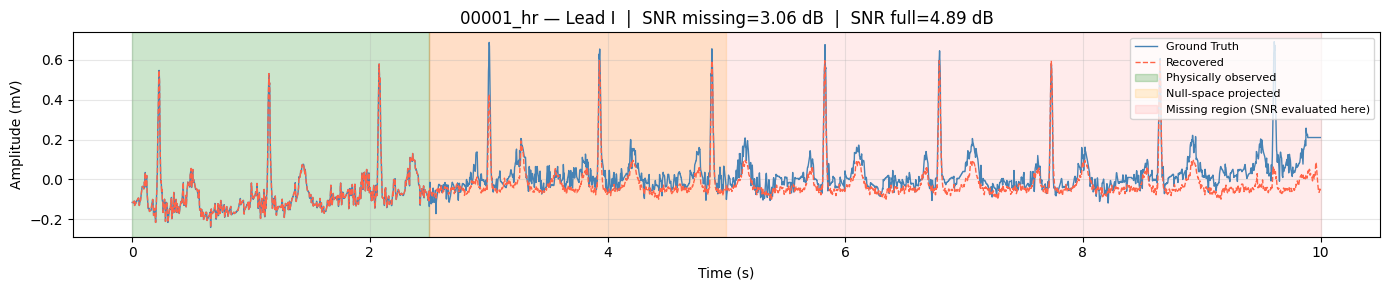

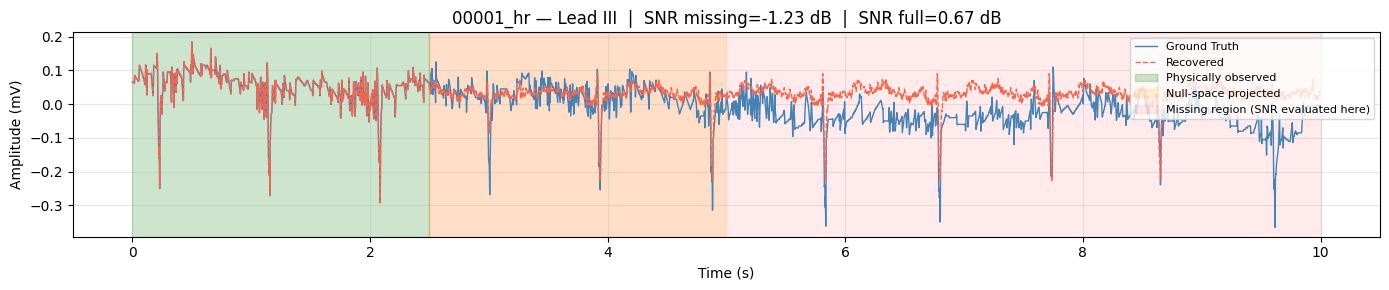

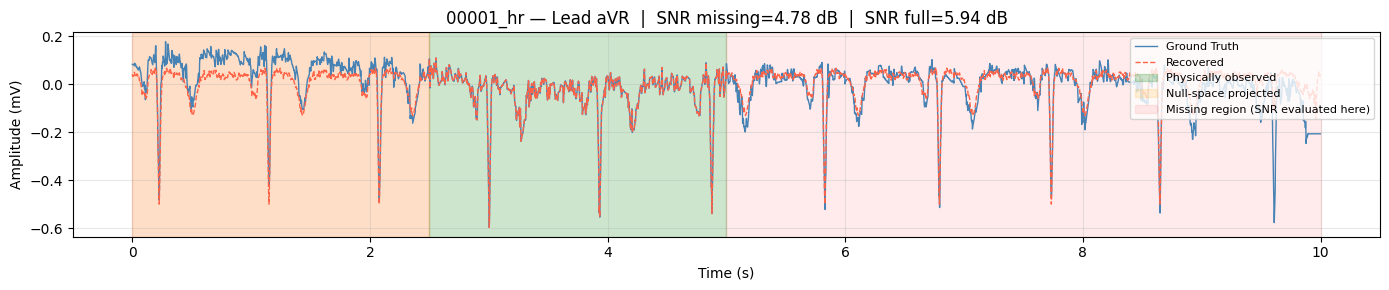

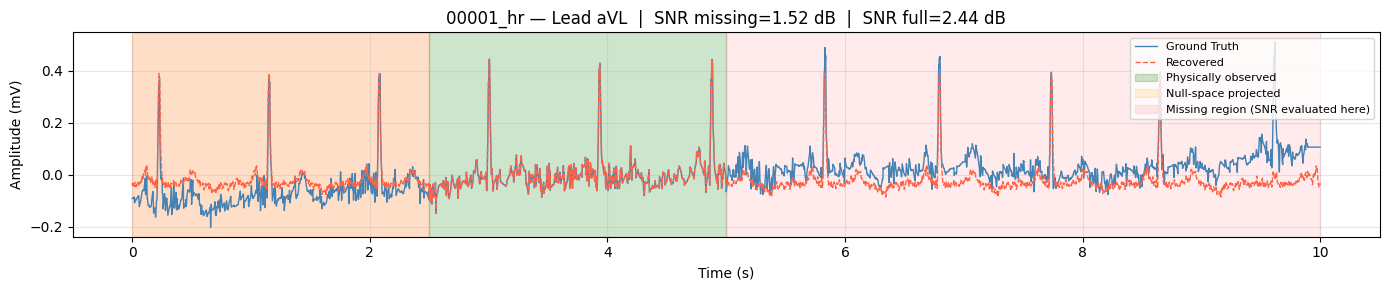

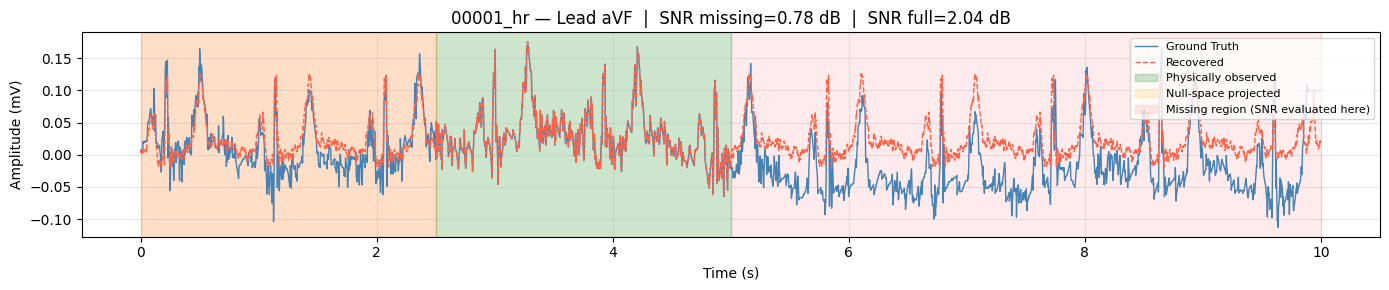

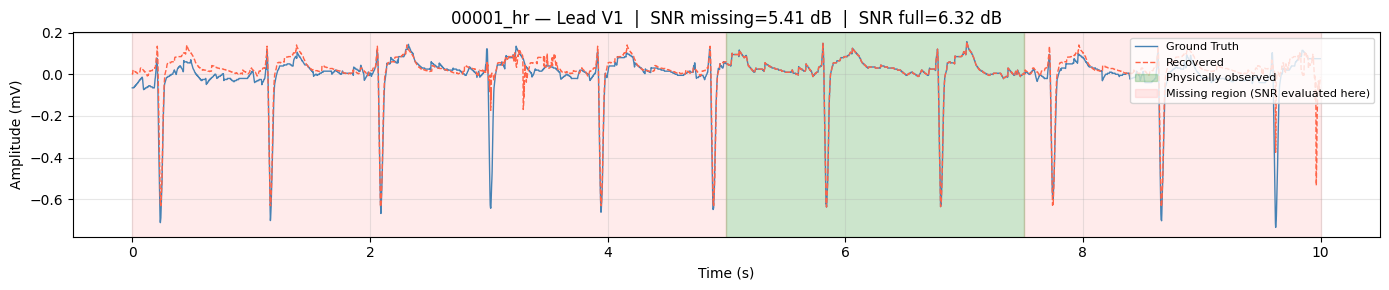

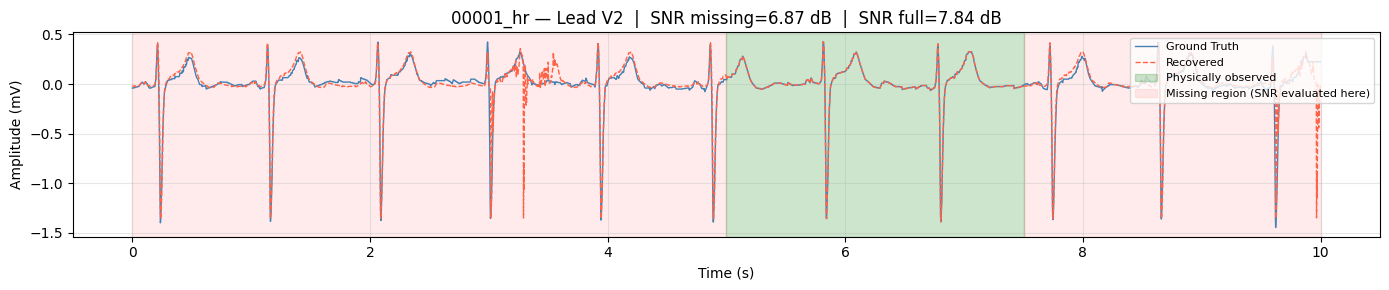

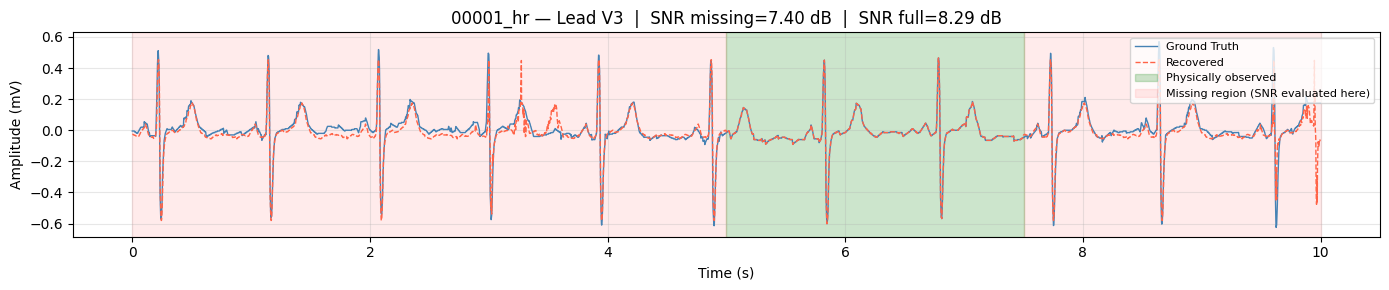

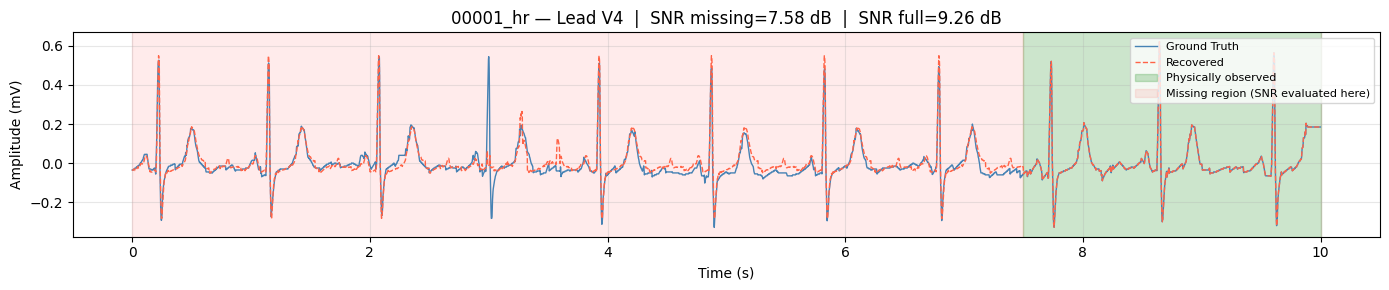

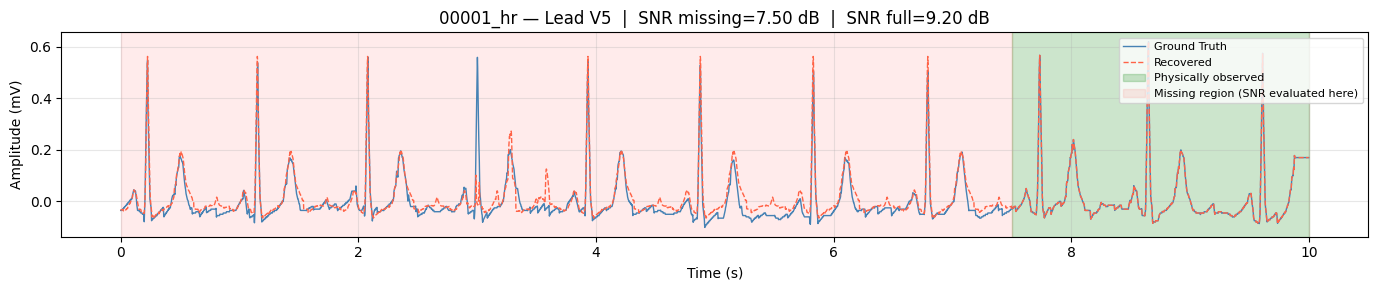

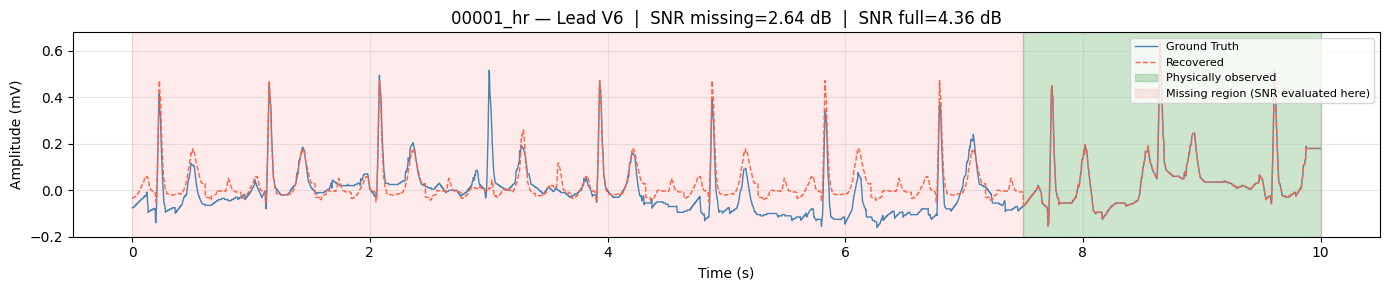


SNR per lead — missing region only (outside extended window):
  I   : 3.06 dB
  II  : fully observed (Lead II)
  III : -1.23 dB
  aVR : 4.78 dB
  aVL : 1.52 dB
  aVF : 0.78 dB
  V1  : 5.41 dB
  V2  : 6.87 dB
  V3  : 7.40 dB
  V4  : 7.58 dB
  V5  : 7.50 dB
  V6  : 2.64 dB

SNR per lead — full 10s:
  I   : 4.89 dB
  II  : fully observed (Lead II)
  III : 0.67 dB
  aVR : 5.94 dB
  aVL : 2.44 dB
  aVF : 2.04 dB
  V1  : 6.32 dB
  V2  : 7.84 dB
  V3  : 8.29 dB
  V4  : 9.26 dB
  V5  : 9.20 dB
  V6  : 4.36 dB

Saved .npy shape : (5000, 12)
Lead order       : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
dtype            : float32


In [14]:
EXAMPLE_RECORD = "/Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean/00000/00001_hr"

print(f"Processing: {EXAMPLE_RECORD}\n")
result = recover_and_save(EXAMPLE_RECORD, leads=ALL_LEADS, plot=True)

if result is not None:
    snrs, snrs_full = result

    print("\nSNR per lead — missing region only (outside extended window):")
    for lead, snr in snrs.items():
        if np.isinf(snr):
            print(f"  {lead:4s}: fully observed (Lead II)")
        elif np.isnan(snr):
            print(f"  {lead:4s}: recovery failed")
        else:
            print(f"  {lead:4s}: {snr:.2f} dB")

    print("\nSNR per lead — full 10s:")
    for lead, snr in snrs_full.items():
        if np.isinf(snr):
            print(f"  {lead:4s}: fully observed (Lead II)")
        elif np.isnan(snr):
            print(f"  {lead:4s}: recovery failed")
        else:
            print(f"  {lead:4s}: {snr:.2f} dB")

    # Verify saved file
    saved = np.load(os.path.join(SAVE_DIR, "00000/00001_hr.npy"))
    print(f"\nSaved .npy shape : {saved.shape}")
    print(f"Lead order       : {ALL_LEADS}")
    print(f"dtype            : {saved.dtype}")

## 7. Full Dataset — Parallelized Recovery + Save

In [15]:
from pathlib import Path

all_hea = sorted(Path(DATA_DIR).rglob('*.mat'))
all_hea = [str(p) for p in all_hea]
random.seed(42)
random.shuffle(all_hea)

print(f"Total records : {len(all_hea)}")
print(f"Saving to     : {SAVE_DIR}\n")

results = Parallel(n_jobs=-1, backend='loky', verbose=5)(
    delayed(recover_and_save)(rec_path, leads=ALL_LEADS, plot=False)
    for rec_path in all_hea
)

print("\nAll done.")

Total records : 21837
Saving to     : /Users/sinahassannia/Desktop/ecg_lead_cover2/recovered_ecg3



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


  [FIDUCIAL ERROR] 11124_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/11000/11124_hr_fiducial.mat'
  [FIDUCIAL ERROR] 08915_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/08000/08915_hr_fiducial.mat'
  [FIDUCIAL ERROR] 08378_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/08000/08378_hr_fiducial.mat'
  [FIDUCIAL ERROR] 17736_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/17000/17736_hr_fiducial.mat'
  [FIDUCIAL ERROR] 11073_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/11000/11073_hr_fiducial.mat'
  [FIDUCIAL ERROR] 14281_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/14000/14281_hr_fiducial.mat'
  [FIDUCIAL ERROR] 19663_hr: [Errno 2] No such file or directory: '/Us

[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    9.5s


  [FIDUCIAL ERROR] 10902_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/10000/10902_hr_fiducial.mat'
  [FIDUCIAL ERROR] 12397_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/12000/12397_hr_fiducial.mat'


...

[Parallel(n_jobs=-1)]: Done 19574 tasks      | elapsed: 10.9min


  [FIDUCIAL ERROR] 15676_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/15000/15676_hr_fiducial.mat'
  [FIDUCIAL ERROR] 21464_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/21000/21464_hr_fiducial.mat'
  [FIDUCIAL ERROR] 11880_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/11000/11880_hr_fiducial.mat'
  [FIDUCIAL ERROR] 13214_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/13000/13214_hr_fiducial.mat'
  [FIDUCIAL ERROR] 20620_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/20000/20620_hr_fiducial.mat'
  [FIDUCIAL ERROR] 15297_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/15000/15297_hr_fiducial.mat'
  [FIDUCIAL ERROR] 03173_hr: [Errno 2] No such file or directory: '/Us

[Parallel(n_jobs=-1)]: Done 20780 tasks      | elapsed: 11.7min


  [FIDUCIAL ERROR] 09784_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/09000/09784_hr_fiducial.mat'
  [FIDUCIAL ERROR] 09269_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/09000/09269_hr_fiducial.mat'
  [FIDUCIAL ERROR] 08960_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/08000/08960_hr_fiducial.mat'
  [FIDUCIAL ERROR] 06483_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/06000/06483_hr_fiducial.mat'
  [FIDUCIAL ERROR] 19327_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/19000/19327_hr_fiducial.mat'
  [FIDUCIAL ERROR] 08672_hr: [Errno 2] No such file or directory: '/Users/sinahassannia/Desktop/ecg_lead_cover2/fiducials_gt3/08000/08672_hr_fiducial.mat'
  [FIDUCIAL ERROR] 19977_hr: [Errno 2] No such file or directory: '/Us

[Parallel(n_jobs=-1)]: Done 21837 out of 21837 | elapsed: 12.3min finished


## 8. Aggregate SNR Results

In [18]:
all_snrs      = {lead: [] for lead in ALL_LEADS if lead != 'II'}
all_snrs_full = {lead: [] for lead in ALL_LEADS if lead != 'II'}

for result in results:
    if result is None:
        continue
    snrs, snrs_full = result
    for lead in all_snrs:
        if not np.isnan(snrs[lead])      and not np.isinf(snrs[lead]):
            all_snrs[lead].append(snrs[lead])
        if not np.isnan(snrs_full[lead]) and not np.isinf(snrs_full[lead]):
            all_snrs_full[lead].append(snrs_full[lead])

# Summary table
summary = []
for lead in ALL_LEADS:
    if lead == 'II':
        continue
    phys_s, phys_e = get_observed_window(lead, fs=500)
    ext_s,  ext_e  = get_extended_observed_window(lead, fs=500)
    v_miss = all_snrs[lead]
    v_full = all_snrs_full[lead]
    summary.append({
        'Lead'                : lead,
        'Physical window'     : f"{phys_s/500:.1f}–{phys_e/500:.1f}s",
        'Extended window'     : f"{ext_s/500:.1f}–{ext_e/500:.1f}s",
        'N records'           : len(v_miss),
        'Mean SNR missing (physical window excluded)' : np.mean(v_miss)   if v_miss else np.nan,
        'Std SNR missing (physical window excluded)'  : np.std(v_miss)    if v_miss else np.nan,
        'Median SNR missing (physical window excluded)': np.median(v_miss) if v_miss else np.nan,
        'Mean SNR full 10s'   : np.mean(v_full)   if v_full else np.nan,
        'Std SNR full 10s'    : np.std(v_full)    if v_full else np.nan,
        'Median SNR full 10s' : np.median(v_full) if v_full else np.nan,
    })

df = pd.DataFrame(summary).set_index('Lead')
print(df.to_string(float_format=lambda x: f"{x:.2f}"))

df.to_csv("lead_recovery_snr_summary_nullspace.csv")
print("\nSaved → lead_recovery_snr_summary_nullspace.csv")

     Physical window Extended window  N records  Mean SNR missing (physical window excluded)  Std SNR missing (physical window excluded)  Median SNR missing (physical window excluded)  Mean SNR full 10s  Std SNR full 10s  Median SNR full 10s
Lead                                                                                                                                                                                                                                             
I           0.0–2.5s        0.0–5.0s      20624                                         9.01                                        4.65                                           8.87              10.33              4.62                10.21
III         0.0–2.5s        0.0–5.0s      20624                                         6.54                                        4.96                                           5.84               7.93              4.92                 7.27
aVR         2.5–5.0s        0.0–

## 9. SNR Box Plot

/var/folders/vc/8z0y3p692pjcv1x3wndz_g2w0000gn/T/ipykernel_64031/2397894069.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=leads_to_plot, patch_artist=True)
/var/folders/vc/8z0y3p692pjcv1x3wndz_g2w0000gn/T/ipykernel_64031/2397894069.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=leads_to_plot, patch_artist=True)


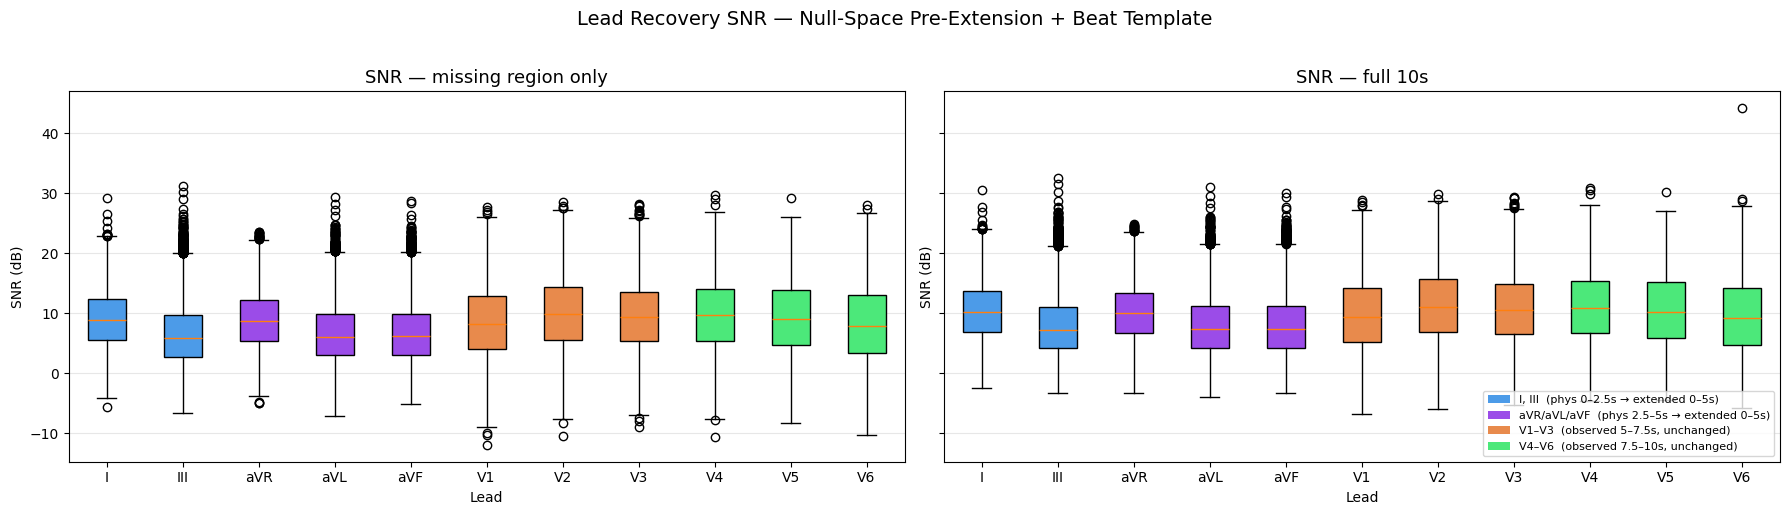

Saved → lead_recovery_snr_boxplot_nullspace.png


In [19]:
leads_to_plot = [l for l in ALL_LEADS if l != 'II']

data_miss = [all_snrs[l]      for l in leads_to_plot]
data_full = [all_snrs_full[l] for l in leads_to_plot]

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

colors = {
    'I'  : '#4C9BE8', 'III': '#4C9BE8',
    'aVR': '#9B4CE8', 'aVL': '#9B4CE8', 'aVF': '#9B4CE8',
    'V1' : '#E88A4C', 'V2' : '#E88A4C', 'V3' : '#E88A4C',
    'V4' : '#4CE87A', 'V5' : '#4CE87A', 'V6' : '#4CE87A',
}

for ax, data, title in zip(
    axes,
    [data_miss, data_full],
    ['SNR — missing region only', 'SNR — full 10s']
):
    bp = ax.boxplot(data, labels=leads_to_plot, patch_artist=True)
    for patch, lead in zip(bp['boxes'], leads_to_plot):
        patch.set_facecolor(colors[lead])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Lead')
    ax.set_ylabel('SNR (dB)')
    ax.grid(True, alpha=0.3, axis='y')

legend_elements = [
    Patch(facecolor='#4C9BE8', label='I, III  (phys 0–2.5s → extended 0–5s)'),
    Patch(facecolor='#9B4CE8', label='aVR/aVL/aVF  (phys 2.5–5s → extended 0–5s)'),
    Patch(facecolor='#E88A4C', label='V1–V3  (observed 5–7.5s, unchanged)'),
    Patch(facecolor='#4CE87A', label='V4–V6  (observed 7.5–10s, unchanged)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('Lead Recovery SNR — Null-Space Pre-Extension + Beat Template',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("lead_recovery_snr_boxplot_nullspace.png", dpi=150)
plt.show()
print("Saved → lead_recovery_snr_boxplot_nullspace.png")